# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

## Data Cleaning

In [1]:
import pandas as pd

train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

train_df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [2]:
# Check for missing values
print(train_df.shape[0])
print(train_df.isnull().sum())

print(test_df.shape[0])
print(test_df.isnull().sum())

103904
Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfact

In [3]:
# Drop rows with missing values
train_df = train_df.dropna().reset_index(drop=True)
test_df = test_df.dropna().reset_index(drop=True)

print(train_df.shape[0])
print(train_df.isnull().sum().sum())

print(test_df.shape[0])
print(test_df.isnull().sum().sum())

103594
0
25893
0


In [4]:
# Check for duplicates
duplicate_count_train = train_df.duplicated().sum()
duplicate_count_test = test_df.duplicated().sum()

print(duplicate_count_train)
print(duplicate_count_test)

0
0


## Forward feature selection(call this function to imply selection in each model)

In [7]:
from sklearn.model_selection import cross_val_score
import numpy as np

def forward_feature_selection(X, y, model, cv=5):
    """
    Perform forward feature selection to select the optimal subset of features.
    
    Parameters:
    - X: Feature dataset (DataFrame)
    - y: Target variable (Series)
    - model: Machine learning model instance, e.g., GaussianNB(), LogisticRegression(), etc.
    - cv: Number of cross-validation folds, default is 5
    
    Returns:
    - selected_features: List of selected optimal features
    - best_score: Cross-validation score of the optimal feature subset
    """
    selected_features = []
    remaining_features = list(X.columns)
    best_score = 0

    while remaining_features:
        scores = []
        for feature in remaining_features:
            # Test the performance of the current selected features with the new feature added
            features_to_test = selected_features + [feature]
            # Use cross-validation to evaluate model performance
            score = np.mean(cross_val_score(model, X[features_to_test], y, cv=cv, n_jobs=-1))
            scores.append((score, feature))
        
        # Find the best feature to add
        scores.sort(reverse=True)
        if scores[0][0] > best_score:
            best_score, best_feature = scores[0]
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
        else:
            break  # Stop if no improvement

    return selected_features, best_score

## One-hot Encoding

In [5]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Define features (X) and target variable (y), ensuring consistent row counts for X and y
X = train_df.drop(columns=['satisfaction', 'id'])  # Remove 'id' and target variable 'satisfaction'
y = train_df['satisfaction']

# Perform One-Hot Encoding on all categorical features
X = pd.get_dummies(X, drop_first=False)

# Define numeric features for standardization
numeric_features = [
    'Age', 'Flight Distance', 'Inflight wifi service', 
    'Departure/Arrival time convenient', 'Ease of Online booking', 
    'Gate location', 'Food and drink', 'Online boarding', 
    'Seat comfort', 'Inflight entertainment', 'On-board service', 
    'Leg room service', 'Baggage handling', 'Checkin service', 
    'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 
    'Arrival Delay in Minutes'
]

# Extract and standardize numeric features
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X[numeric_features])

# Convert standardized numeric features back to DataFrame
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_features)

# Concatenate standardized numeric features with One-Hot encoded categorical features
X_final_scaled = pd.concat([X_numeric_scaled_df, X.drop(columns=numeric_features)], axis=1)

# Display a preview of the final processed dataset
print("\nPreview of X_final_scaled (first 5 rows):")
print(X_final_scaled.head())

print("\nPreview of X (first 5 rows):")
print(X.head())


Preview of X_final_scaled (first 5 rows):
        Age  Flight Distance  Inflight wifi service  \
0 -1.745542        -0.731305               0.203521   
1 -0.951526        -0.956916               0.203521   
2 -0.885358        -0.047454              -0.549571   
3 -0.951526        -0.629028              -0.549571   
4  1.430521        -0.977973               0.203521   

   Departure/Arrival time convenient  Ease of Online booking  Gate location  \
0                           0.616249                0.173716      -1.547312   
1                          -0.695032                0.173716       0.017981   
2                          -0.695032               -0.541118      -0.764666   
3                           1.271890                1.603383       1.583273   
4                          -0.039391                0.173716       0.017981   

   Food and drink  Online boarding  Seat comfort  Inflight entertainment  ...  \
0        1.352401        -0.185632      1.182991                1.2315

## NB Method

In [10]:
# from sklearn.naive_bayes import GaussianNB
# 
# # Use Naive Bayes for forward feature selection
# nb_model = GaussianNB()
# selected_features_nb, best_score_nb = forward_feature_selection(X_final_scaled, y, nb_model)
# print("Naive Bayes selected features:", selected_features_nb)
# print("Naive Bayes best cross-validation score:", best_score_nb)

In [11]:
# from sklearn.neighbors import KNeighborsClassifier
# 
# # Use KNN for forward feature selection
# knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', n_jobs=-1)
# selected_features_knn, best_score_knn = forward_feature_selection(X_final_scaled, y, knn_model)
# print("KNN selected features:", selected_features_knn)
# print("KNN best cross-validation score:", best_score_knn)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import numpy as np

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "K-NN": KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1),
    # "SVM": SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
}
model_results = {}

for model_name, model in models.items():
    print(f"Performing forward feature selection with {model_name}...")
    selected_features, best_score = forward_feature_selection(X_final_scaled, y, model, cv=3)
    model_results[model_name] = {
        "selected_features": selected_features,
        "best_score": best_score
    }
    print(f"{model_name} - Best Score: {best_score}")
    print(f"{model_name} - Selected Features: {selected_features}\n")

feature_counts = {}

for model_name, result in model_results.items():
    for feature in result["selected_features"]:
        if feature not in feature_counts:
            feature_counts[feature] = 0
        feature_counts[feature] += 1

threshold = 3
final_selected_features = [feature for feature, count in feature_counts.items() if count >= threshold]

# 输出最终筛选的特征
print(f"Final selected features (appeared in at least 3 models): {final_selected_features}")

## Model Evaluation Functions

In [37]:
from sklearn.metrics import roc_auc_score,accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

def evaluate_model_top(X, y,X_test,y_test, model, model_name):
    print(f"Performing evaluation model top 5 feature {model_name}...")
    return evaluate_model(X, y, X_test, y_test, model, model_name)

def evaluate_model_individual(X, y, X_test, y_test, model, model_name):
    print(f"Performing evaluation model individual {model_name}...")
    return evaluate_model(X, y, X_test, y_test, model, model_name)

def evaluate_model(X_train, y_train, X_test, y_test, model, model_name) -> dict[str, any]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1] # Calculate AUC
    y_test_binary = [1 if label == 'satisfied' else 0 for label in y_test]
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_probs)
    report = classification_report(y_test, y_pred,output_dict=True)
    evaluate_result = {
        "Accuracy":  accuracy_score(y_test,y_pred),
        "Precision":  report['macro avg']['precision'],
        "Recall":  report['macro avg']['recall'],
        "F Score":  report['macro avg']['f1-score'],
        "AUC":  float(roc_auc_score(y_test,y_probs)),
        "FPR": fpr,
        "TPR": tpr
    }
    print(f"{model_name} - Result: {evaluate_result}\n")
    return evaluate_result

def roc_graph(evaluate_result, model_name):
    # Plot the ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(evaluate_result["FPR"], evaluate_result["TPR"], label=f"Model (AUC = {evaluate_result["AUC"]:.2f})", color='blue')
    # plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Random Baseline')
    plt.xlim([-0.1, 1.1]) 
    plt.ylim([-0.1, 1.1]) 
    plt.xticks([i/10.0 for i in range(0, 11)]) 
    plt.yticks([i/10.0 for i in range(0, 11)])
    plt.fill_between(evaluate_result["FPR"], evaluate_result["TPR"] - 0.03, evaluate_result["TPR"] + 0.03, color='blue', alpha=0.2, label="Confidence Interval")
    plt.title(f"{model_name} (ROC Curve)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()

def gen_table(input):
    # Convert dictionary to DataFrame and transpose
    df = pd.DataFrame(input).T
    df.reset_index(inplace=True)
    df.rename(columns={"index": "Model"}, inplace=True)
    # Convert all metric values to percentages and append '%' sign
    for column in df.columns[1:]:
        if(column != "AUC"): 
            df[column] = df[column].apply(lambda x: f"{x * 100:.2f}%")
        else:
            df[column] = df[column].round(3)
    # Display the table
    print(df.to_string(index=False))

## Models Performance Evaluation 

In [21]:
# Result from Above forward-selection - Remove later
final_selected_features = ['Online boarding', 'Type of Travel_Personal Travel', 'Inflight wifi service', 'Baggage handling', 'Customer Type_disloyal Customer', 'Gate location', 'Class_Business', 'Checkin service', 'Leg room service']
model_results= {}
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "K-NN": KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1),
    # "SVM": SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)
}
model_results["Decision Tree"] = {
        "selected_features": ['Online boarding', 'Type of Travel_Personal Travel', 'Inflight wifi service', 'Baggage handling', 'Customer Type_disloyal Customer', 'Gate location', 'Class_Business', 'Age', 'Checkin service', 'Leg room service', 'Departure Delay in Minutes', 'Ease of Online booking'],
        "best_score": ""
    }
model_results["Random Forest"] = {
        "selected_features": ['Online boarding', 'Type of Travel_Personal Travel', 'Inflight wifi service', 'Gate location', 'Baggage handling', 'Customer Type_Loyal Customer', 'Class_Business', 'Age', 'Inflight service', 'Checkin service', 'Leg room service', 'Type of Travel_Business travel'],
        "best_score": ""
    }
model_results["K-NN"] = {
        "selected_features": ['Online boarding', 'Type of Travel_Personal Travel', 'Inflight wifi service', 'Gate location', 'On-board service', 'Customer Type_disloyal Customer', 'Class_Business', 'Baggage handling', 'Inflight service'],
        "best_score": ""
    }
model_results["Naive Bayes"] = {
        "selected_features": ['Online boarding', 'Checkin service', 'Inflight wifi service', 'Class_Eco', 'Inflight entertainment', 'Type of Travel_Personal Travel', 'Customer Type_disloyal Customer', 'On-board service', 'Leg room service'],
        "best_score": ""
    }
model_results["Logistic Regression"] = {
        "selected_features": ['Online boarding', 'Type of Travel_Personal Travel', 'Inflight wifi service'],
        "best_score": ""
    }
# Result from Above forward-selection - Remove later

evaluate_results = {}
evaluate_top_feature_results = {}
X_test = test_df.drop(columns=['satisfaction', 'id'])
y_test = test_df['satisfaction']
# Split the data into training and test sets
X_top_filtered = X[final_selected_features[:5]]
X_test = pd.get_dummies(X_test, drop_first=False)

# Prediction models of classification algorithms after feature selection
for model_name, model in models.items():
    X_filtered = X[model_results[model_name]["selected_features"]]
    X_test_filtered = X_test[model_results[model_name]["selected_features"]]
    evaluate_results[model_name] = evaluate_model_individual(X_filtered,
                                                             y,
                                                             X_test_filtered,
                                                             y_test,
                                                             model,
                                                             model_name)
# Prediction models of classification algorithms for the top 5 selected features
for model_name, model in models.items():
    X_test_top = X_test[final_selected_features[:5]]
    evaluate_top_feature_results[model_name] = evaluate_model_top(X_top_filtered,
                                                             y,
                                                             X_test_top,
                                                             y_test,
                                                             model,
                                                             model_name)

Performing evaluation model individual Decision Tree...
Decision Tree - Result: {'Accuracy': 0.9487120071061677, 'Precision': 0.9492927276806744, 'Recall': 0.9465270546939654, 'F Score': 0.9477811973516643, 'AUC': 0.9883829287401811, 'FPR': array([0.        , 0.00144548, 0.00144548, 0.00144548, 0.00151432,
       0.0033728 , 0.00399229, 0.00412996, 0.00419879, 0.00419879,
       0.00474945, 0.00502478, 0.00502478, 0.00502478, 0.00516244,
       0.00536894, 0.00550661, 0.0063326 , 0.0063326 , 0.0063326 ,
       0.00736509, 0.00743392, 0.00743392, 0.00757159, 0.00791575,
       0.00819108, 0.00846641, 0.00936123, 0.00936123, 0.00977423,
       0.00991189, 0.01232104, 0.01280286, 0.01424835, 0.01431718,
       0.01672632, 0.01789648, 0.01947963, 0.02016795, 0.02347192,
       0.02464207, 0.02498623, 0.02505507, 0.02705121, 0.02835903,
       0.02877203, 0.02897852, 0.02918502, 0.02980452, 0.03345264,
       0.03379681, 0.03558645, 0.03675661, 0.03765143, 0.03875275,
       0.04061123, 0.0

In [9]:
print(f"Prediction models algorithms after feature selection\n")
gen_table(evaluate_results)
print(f"\nPrediction models algorithms top 5 features\n")
gen_table(evaluate_top_feature_results)

Prediction models algorithms after feature selection

              Model Accuracy Precision Recall F Score   AUC
      Decision Tree   94.87%    94.93% 94.65%  94.78% 0.988
      Random Forest   95.22%    95.20% 95.09%  95.14% 0.990
               K-NN   94.10%    94.12% 93.90%  94.00% 0.974
        Naive Bayes   87.21%    87.25% 86.73%  86.94% 0.931
Logistic Regression   84.59%    84.50% 84.11%  84.27% 0.880

Prediction models algorithms top 5 features

              Model Accuracy Precision Recall F Score   AUC
      Decision Tree   93.09%    93.10% 92.87%  92.97% 0.982
      Random Forest   93.25%    93.25% 93.03%  93.13% 0.983
               K-NN   92.67%    92.55% 92.58%  92.56% 0.970
        Naive Bayes   84.72%    84.46% 84.60%  84.52% 0.925
Logistic Regression   83.84%    83.64% 83.49%  83.56% 0.909


In [33]:
df_results = pd.DataFrame(evaluate_results).transpose()
print(df_results)

                     Accuracy  Precision    Recall   F Score       AUC
Decision Tree        0.948789   0.949383  0.946596  0.947859  0.988497
Random Forest        0.952188   0.951985  0.950870  0.951405  0.989889
K-NN                 0.941027   0.941151  0.938998  0.939992  0.974481
Naive Bayes          0.872128   0.872456  0.867274  0.869355  0.931117
Logistic Regression  0.845866   0.845023  0.841064  0.842692  0.880208


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

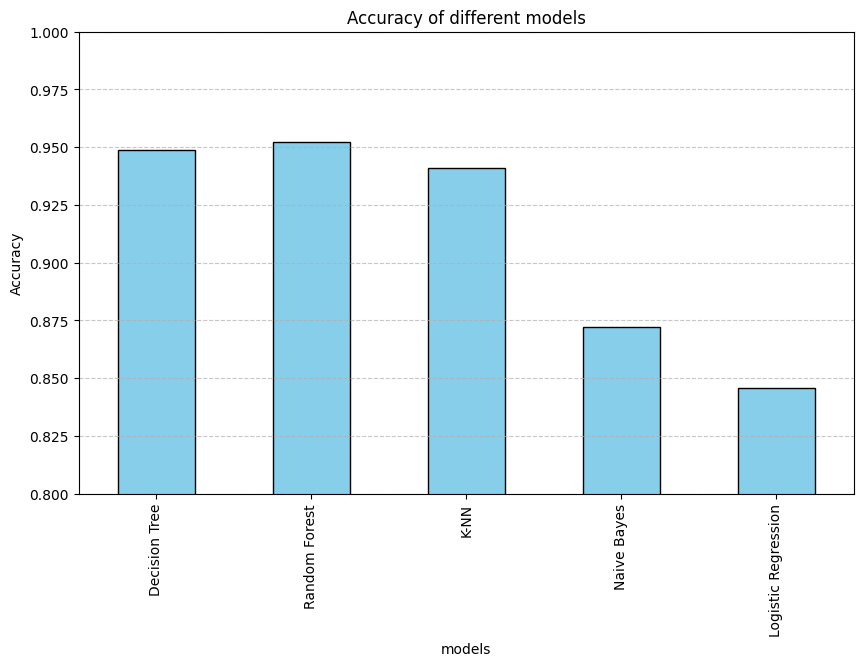

In [34]:
import matplotlib.pyplot as plt

#  Accuracy bar chart
df_results['Accuracy'].plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='k')
plt.title('Accuracy of different models')
plt.xlabel('models')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

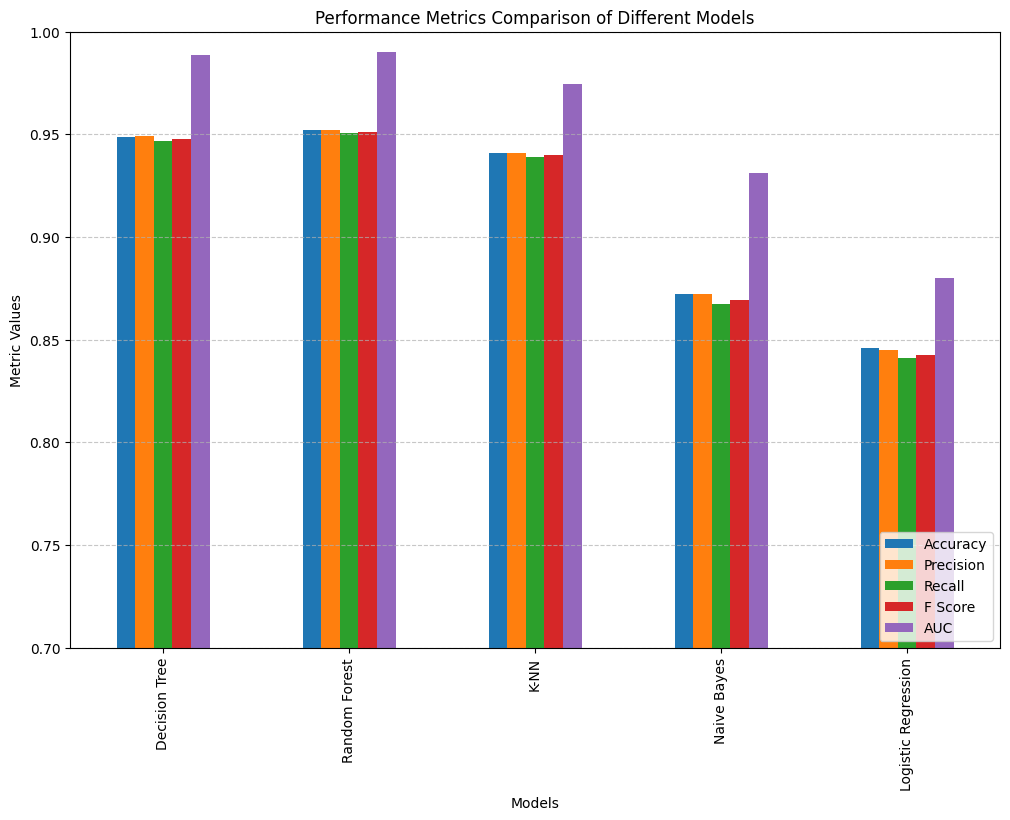

In [29]:
# Select metrics to compare
metrics = ['Accuracy', 'Precision', 'Recall', 'F Score', 'AUC']

# Plot multiple metrics as a bar chart
df_results[metrics].plot(kind='bar', figsize=(12, 8))
plt.title('Performance Metrics Comparison of Different Models')
plt.xlabel('Models')
plt.ylabel('Metric Values')
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the foll

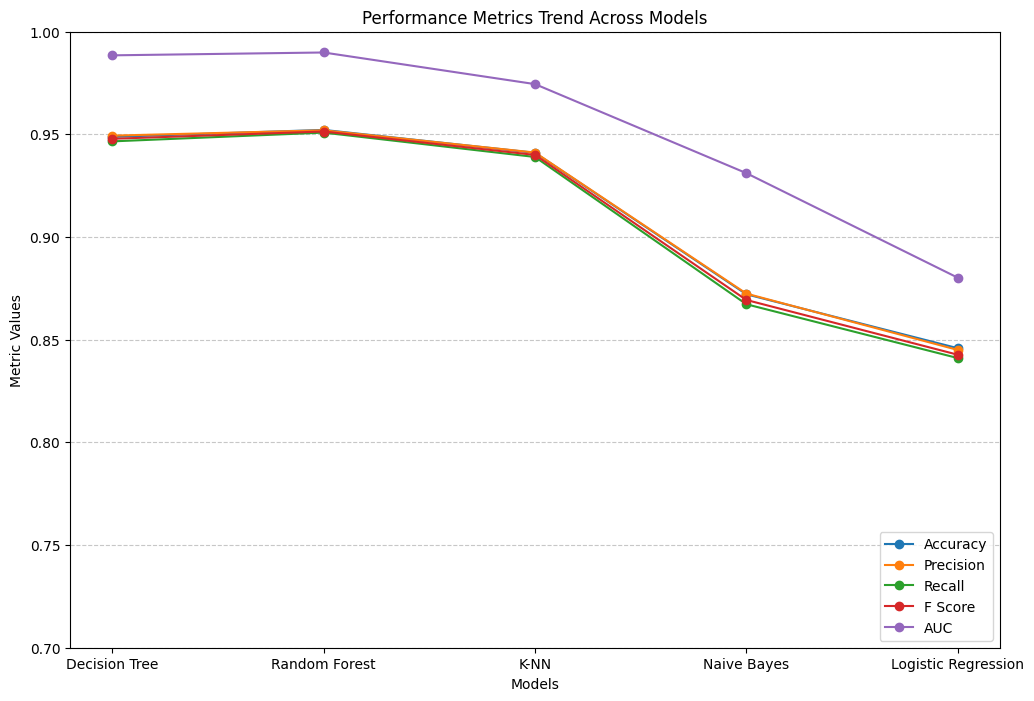

In [31]:
# Plot the metrics as a line chart
df_results[metrics].plot(kind='line', figsize=(12, 8), marker='o')
plt.title('Performance Metrics Trend Across Models')
plt.xlabel('Models')
plt.ylabel('Metric Values')
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(range(len(df_results)), df_results.index)
plt.show()


## ROC Individual Feature

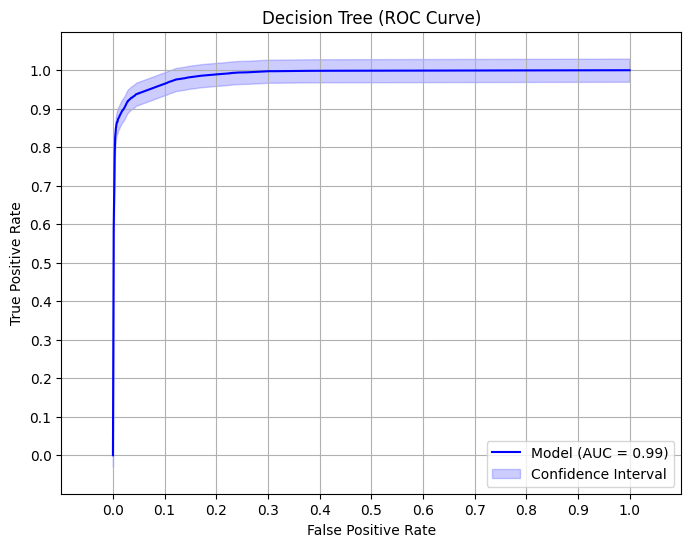

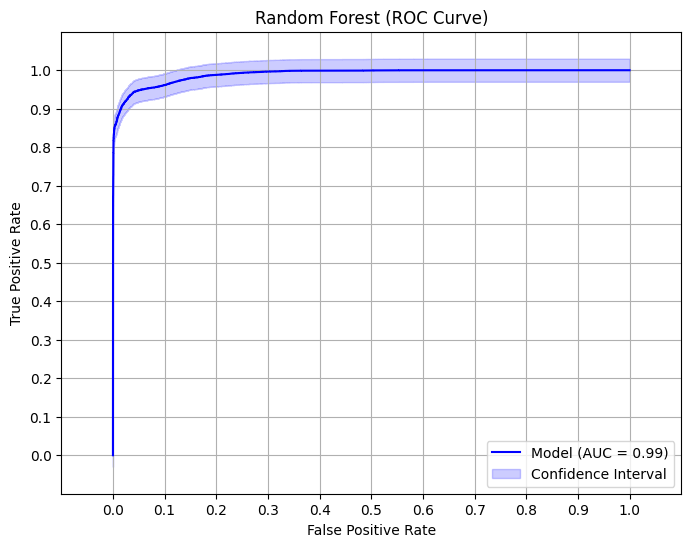

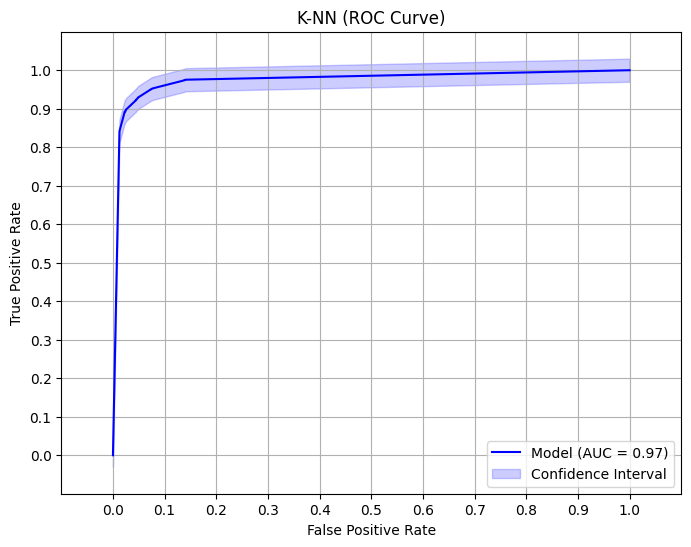

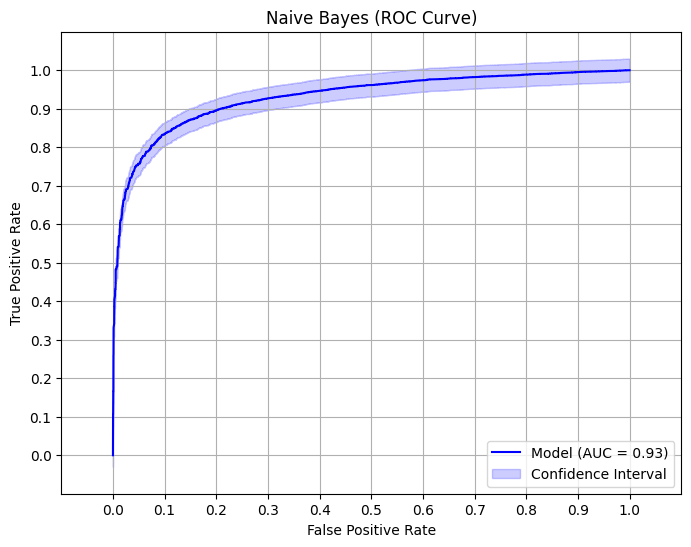

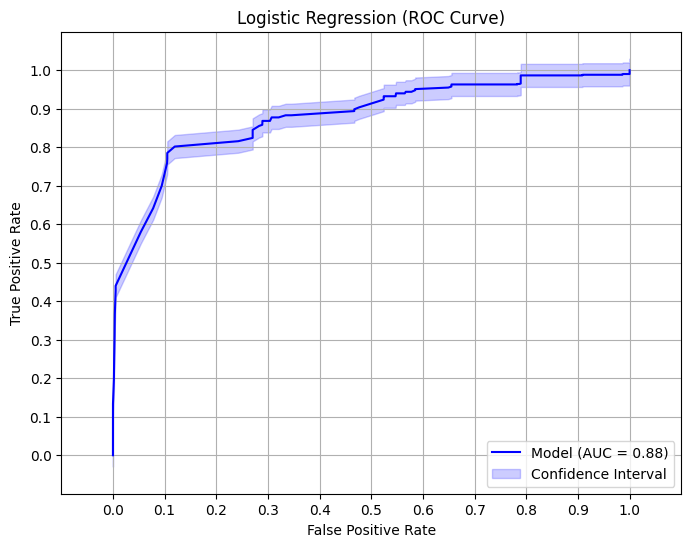

In [38]:
# ROC Graph for individual feature
for model_name, evaluate_result in evaluate_results.items():
    roc_graph(evaluate_result,model_name)

## ROC Top 5 Features

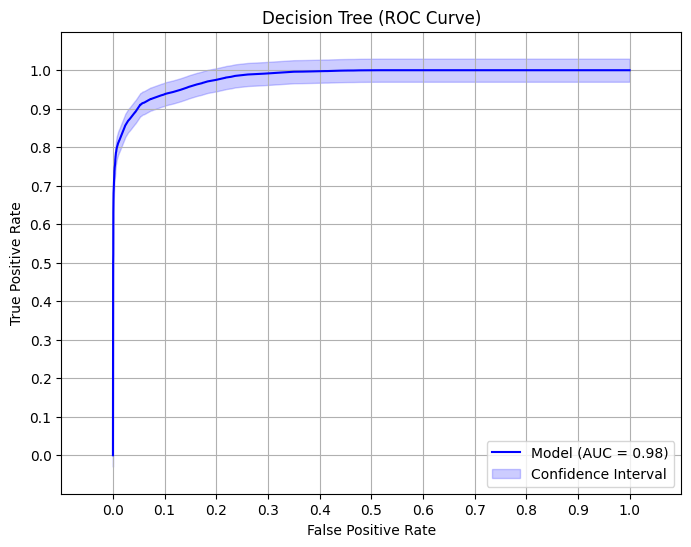

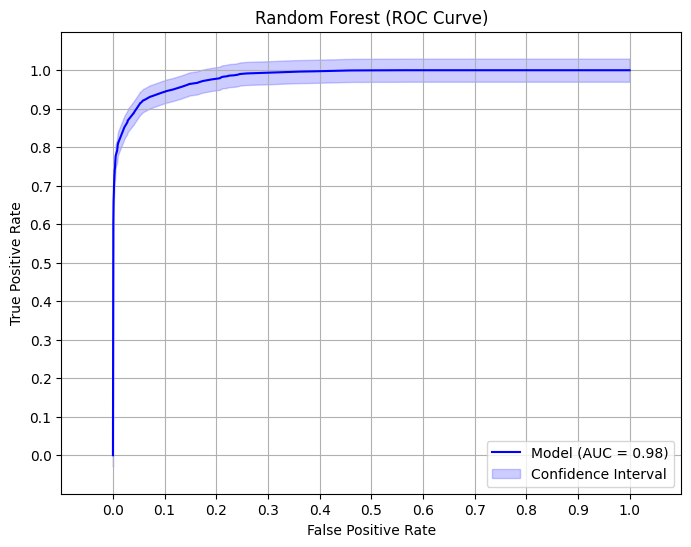

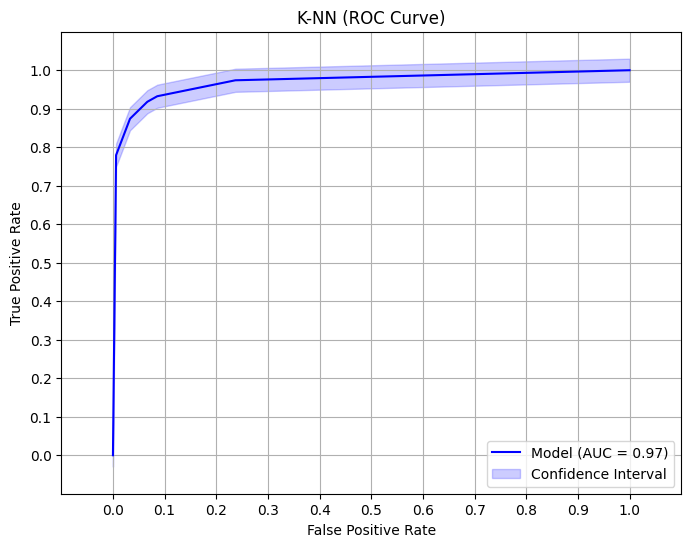

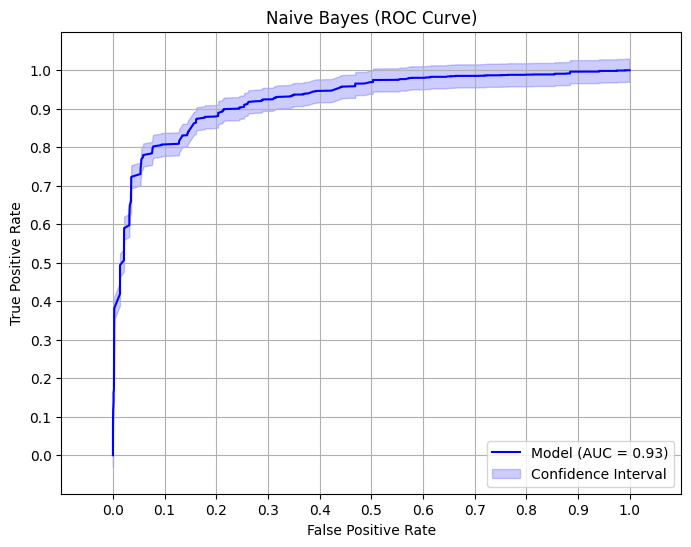

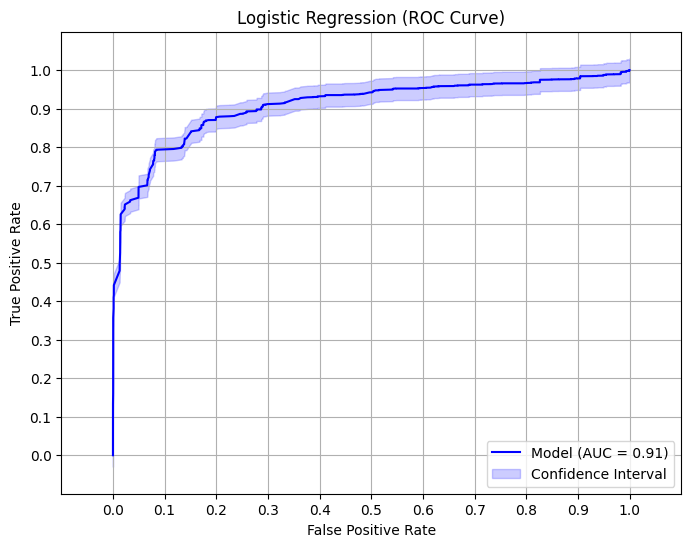

In [39]:
# # ROC Graph for top 5 features
for model_name, evaluate_result in evaluate_top_feature_results.items():
    roc_graph(evaluate_result,model_name)